원문제  
Enginola Television Company는 두 종류의   
max z = 20x1+30x2  
s.t. x1<=60  
     x2<=50  
     x1+x2<=0

쌍대문제  
minimize z = 60PA+50PC+120PL  
s.t. PA+PL>=20  
     PC+2PL>=20  

In [ ]:
from ortools.linear_solver import pywraplp

# 솔버 생성 (GLOP = Google LP solver)
solver = pywraplp.Solver.CreateSolver('GLOP')

# 결정 변수
INF = solver.infinity()
x1 = solver.NumVar(0,INF,'x1') # 제품A 생산량
x2 = solver.NumVar(0,INF, 'x2') # 제품B 생산량

# 제약 조건
c1 = solver.Add(2*x1 + x2 <=8, '기계_제약')
c2 = solver.Add(x1+3*x2<=9,'조립_제약')

# 목적 함수
solver.Maximize(3*x1+5*x2)

# 풀기
status = solver.Solve()

STATUS_NAME = {
    pywraplp.Solver.OPTIMAL: 'OPTIMAL',
    pywraplp.Solver.FEASIBLE: 'FEASIBLE (not optimal)',
    pywraplp.Solver.INFEASIBLE: 'INFEASIBLE',
    pywraplp.Solver.UNBOUNDED: 'UNBOUNDED',
}

print('='*45)
print(f'상태: {STATUS_NAME.get(status, status)}')
print('='*45)

if status == pywraplp.Solver.OPTIMAL:
    print(f'제품 A (x1): {x1.solution_value():.4f}개')
    print(f'제품 B (x2): {x2.solution_value():.4f}개')
    print(f'최대 이익 : {solver.Objective().Value():.4f} 만원')
    print('-'*45)
    print('[쌍대값 / Shadow Price]')
    print(f'y1 (기계 제약): {c1.dual_value():.4f} 만원/시간')
    print(f'y2 (조립 제약): {c2.dual_value():.4f} 만원/시간')
    print('-'*45)
    print('[환산 비용 / Reduced Cost]')
    print(f'rc(x1): {x1.reduced_cost():.4f}')
    print(f'rc(x2): {x2.reduced_cost():.4f}')

원문제    
max z = 3x1+5x2  
s.t. 2x1+x2<=8  
     x1+3x2<=9  
     x1,x2>=0

쌍대문제  
min z=8y1+9y2  
s.t. 2y1+y2 >= 3  
     y1+3y2 >= 5    
     y1,y2>=0

In [14]:
from ortools.linear_solver import pywraplp

# 솔버 생성 (GLOP = Google LP solver)
solver = pywraplp.Solver.CreateSolver('GLOP')

# 결정 변수
INF = solver.infinity()
x1 = solver.NumVar(0,INF,'x1') # 제품A 생산량
x2 = solver.NumVar(0,INF, 'x2') # 제품B 생산량

# 제약 조건
c1 = solver.Add(2*x1 + x2 <=8, '기계_제약')
c2 = solver.Add(x1+3*x2<=9,'조립_제약')

# 목적 함수
solver.Maximize(3*x1+5*x2)

# 풀기
status = solver.Solve()

STATUS_NAME = {
    pywraplp.Solver.OPTIMAL: 'OPTIMAL',
    pywraplp.Solver.FEASIBLE: 'FEASIBLE (not optimal)',
    pywraplp.Solver.INFEASIBLE: 'INFEASIBLE',
    pywraplp.Solver.UNBOUNDED: 'UNBOUNDED',
}

print('='*45)
print(f'상태: {STATUS_NAME.get(status, status)}')
print('='*45)

if status == pywraplp.Solver.OPTIMAL:
    print(f'제품 A (x1): {x1.solution_value():.4f}개')
    print(f'제품 B (x2): {x2.solution_value():.4f}개')
    print(f'최대 이익 : {solver.Objective().Value():.4f} 만원')
    print('-'*45)
    print('[쌍대값 / Shadow Price]')
    print(f'y1 (기계 제약): {c1.dual_value():.4f} 만원/시간')
    print(f'y2 (조립 제약): {c2.dual_value():.4f} 만원/시간')
    print('-'*45)
    print('[환산 비용 / Reduced Cost]')
    print(f'rc(x1): {x1.reduced_cost():.4f}')
    print(f'rc(x2): {x2.reduced_cost():.4f}')

상태: OPTIMAL
제품 A (x1): 3.0000개
제품 B (x2): 2.0000개
최대 이익 : 19.0000 만원
---------------------------------------------
[쌍대값 / Shadow Price]
y1 (기계 제약): 0.8000 만원/시간
y2 (조립 제약): 1.4000 만원/시간
---------------------------------------------
[환산 비용 / Reduced Cost]
rc(x1): 0.0000
rc(x2): 0.0000


목적함수 계수 민감도 - c1(제품A이익) 변화

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
import platform

if platform.system() =='Windows':
    plt.rcParams['font.family'] = 'NanumGothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

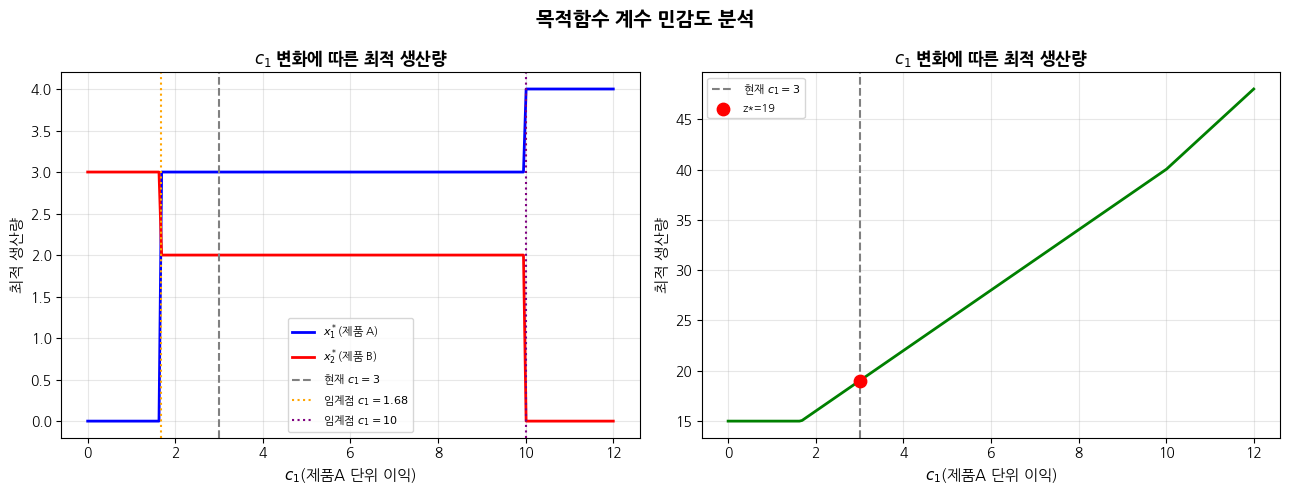

c1의 허용 범위: 1.68<=c1<=10.0(현재 기저 유지)
c1<1.68 -> 기저 변경: x1=0, x2=3이 최적
c1>10.0 -> 기저 변경: x1=4, x2=0이 최적


In [25]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

def solve_lp(c1_val, c2_val=5, b1=8, b2=9):
    #LP를 주어진 파라미터로 풀고 (x1,x2,z) 반환
    s = pywraplp.Solver.CreateSolver('GLOP')
    INF = s.infinity()
    x1 = s.NumVar(0,INF, 'x1')
    x2 = s.NumVar(0,INF, 'x2')
    
    s.Add(2*x1+x2 <= b1)
    s.Add(x1+3*x2 <= b2)
    s.Maximize(c1_val*x1 + c2_val*x2)
    
    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        return x1.solution_value(), x2.solution_value(), s.Objective().Value()
    
    return None, None, None

c1_range = np.linspace(0,12,200)
x1_vals, x2_vals, z_vals = [], [], []
for c1v in c1_range:
    xv1, xv2, zv = solve_lp(c1v)
    x1_vals.append(xv1); x2_vals.append(xv2); z_vals.append(zv)
    # if xv1 != 0:
    #     print(c1v)


fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
ax.plot(c1_range, x1_vals, 'b-', lw=2, label=r'$x_1^*$(제품 A)')
ax.plot(c1_range, x2_vals, 'r-', lw=2, label=r'$x_2^*$(제품 B)')
ax.axvline(3,color='gray', ls='--', label='현재 $c_1=3$')
ax.axvline(1.68,color='orange', ls=':', lw=1.5, label='임계점 $c_1=1.68$')
ax.axvline(10,color='purple', ls=':', lw=1.5, label='임계점 $c_1=10$')
ax.set_xlabel(r'$c_1$(제품A 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_1$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(c1_range, z_vals, 'g-', lw=2)
ax.axvline(3, color='gray', ls='--', label='현재 $c_1=3$')
ax.scatter([3],[19],color='red', s=80, zorder=5, label='z*=19')
ax.set_xlabel(r'$c_1$(제품A 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_1$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('목적함수 계수 민감도 분석', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('c1의 허용 범위: 1.68<=c1<=10.0(현재 기저 유지)')
print('c1<1.68 -> 기저 변경: x1=0, x2=3이 최적')
print('c1>10.0 -> 기저 변경: x1=4, x2=0이 최적')


RHS 민감도 - Shadow Price 유효 범위

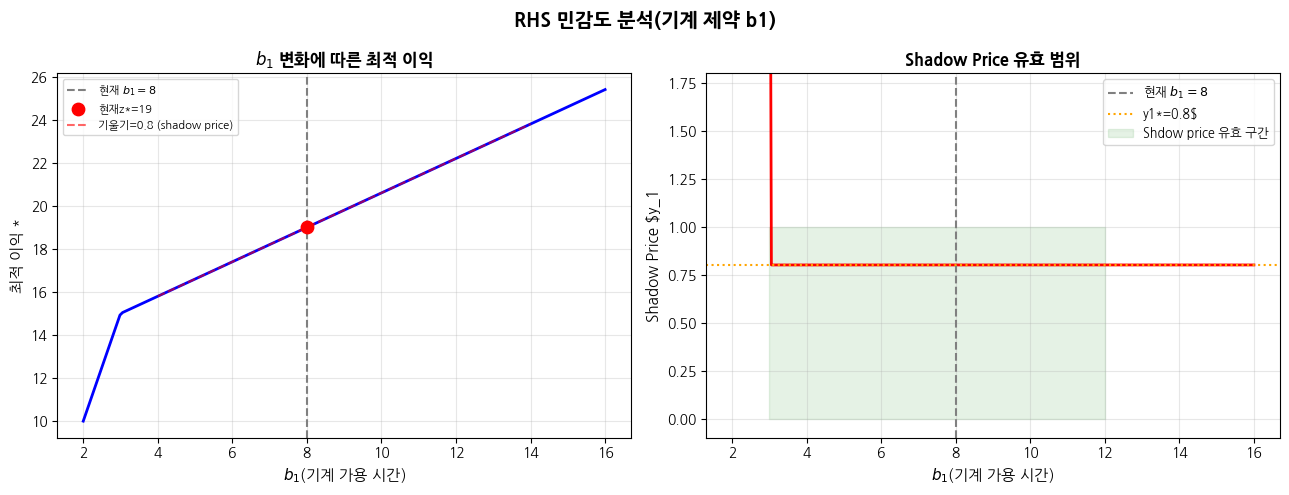

기계 제약 (b1=8): shadow price y1* = 0.80 만원/시간
조립 제약 (b2=9): shadow price y2* = 1.40 만원/시간
-> 기계 1시간 추가 -> 이익 +0.80만원
-> 조립 1시간 추가 -> 이익 +1.40만원
조립 인력 확충이 더 효과적!


In [19]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

b1_range = np.linspace(2, 16, 200)
z_b1, sp_b1 = [], []

for b1v in b1_range:
    s = pywraplp.Solver.CreateSolver('GLOP')

    # 결정 변수
    INF = s.infinity()
    x1 = s.NumVar(0,INF,'x1') 
    x2 = s.NumVar(0,INF, 'x2')

    # 제약 조건
    ct1 = s.Add(2*x1 + x2 <= b1v)
    s.Add(x1+3*x2<=9)

    # 목적 함수
    s.Maximize(3*x1 + 5 * x2)

    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        z_b1.append(s.Objective().Value())
        sp_b1.append(ct1.dual_value())
    else:
        z_b1.append(np.nan); sp_b1.append(np.nan) 

fig, axes = plt.subplots(1,2, figsize=(13,5))

ax = axes[0]
ax.plot(b1_range, z_b1, 'b-', lw=2)
ax.axvline(8,color='gray', ls='--', label='현재 $b_1=8$')
ax.scatter([8],[19],color='red', s=80, zorder=5, label='현재z*=19')
b1_tan=np.array([4,14])
ax.plot(b1_tan, 19+0.8*(b1_tan-8), 'r--', alpha=0.6, label='기울기=0.8 (shadow price)')
ax.set_xlabel(r'$b_1$(기계 가용 시간)', fontsize=11)
ax.set_ylabel('최적 이익 *', fontsize=11)
ax.set_title(r'$b_1$ 변화에 따른 최적 이익', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(b1_range, sp_b1, 'r-', lw=2)
ax.axvline(8, color='gray', ls='--', label='현재 $b_1=8$')
ax.axhline(0.8, color='orange', ls=':', label='y1*=0.8$')
ax.fill_between([3,12], [0,0], [1,1], alpha=0.1, color='green', label='Shdow price 유효 구간')
ax.set_xlabel(r'$b_1$(기계 가용 시간)', fontsize=11)
ax.set_ylabel('Shadow Price $y_1', fontsize=11)
ax.set_title('Shadow Price 유효 범위', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-0.1, 1.8)

plt.suptitle('RHS 민감도 분석(기계 제약 b1)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('기계 제약 (b1=8): shadow price y1* = 0.80 만원/시간')
print('조립 제약 (b2=9): shadow price y2* = 1.40 만원/시간')
print('-> 기계 1시간 추가 -> 이익 +0.80만원')
print('-> 조립 1시간 추가 -> 이익 +1.40만원')
print('조립 인력 확충이 더 효과적!')

실습 문제. 제품 생산 계획 최적화

원문제    
max z = 40P+50Q+60R  
s.t. 2P+Q+3R <=120   
     P+2Q+2R<=80   
     P+3Q+R<=100    
     P,Q,R>=0

쌍대문제  
min z=120y1+80y2+100y3  
s.t. 2y1+y2+y3 >= 40  
     y1+2y2+3y3 >= 50
     3y1+2y2+1y3 >= 60    
     y1,y2>=0

In [20]:
from ortools.linear_solver import pywraplp

# 솔버 생성 (GLOP = Google LP solver)
solver = pywraplp.Solver.CreateSolver('GLOP')

# 결정 변수
INF = solver.infinity()
P = solver.NumVar(0,INF,'P') # 제품P 생산량
Q = solver.NumVar(0,INF, 'Q') # 제품Q 생산량
R = solver.NumVar(0,INF, 'R') # 제품R 생산량

# 제약 조건
c1 = solver.Add(2*P+Q+3*R <=120, '원자재_제약')
c2 = solver.Add(P+2*Q+2*R<=80,'노동력_제약')
c3 = solver.Add(P+3*Q+R<=100,'기계_제약')

# 목적 함수
solver.Maximize(40*P+50*Q+60*R )

# 풀기
status = solver.Solve()

STATUS_NAME = {
    pywraplp.Solver.OPTIMAL: 'OPTIMAL',
    pywraplp.Solver.FEASIBLE: 'FEASIBLE (not optimal)',
    pywraplp.Solver.INFEASIBLE: 'INFEASIBLE',
    pywraplp.Solver.UNBOUNDED: 'UNBOUNDED',
}

print('='*45)
print(f'상태: {STATUS_NAME.get(status, status)}')
print('='*45)

if status == pywraplp.Solver.OPTIMAL:
    print(f'제품 P: {P.solution_value():.4f}개')
    print(f'제품 Q: {Q.solution_value():.4f}개')
    print(f'제품 R: {R.solution_value():.4f}개')
    print(f'최대 이익 : {solver.Objective().Value():.4f} 만원')
    print('-'*45)
    print('[쌍대값 / Shadow Price]')
    print(f'y1 (원자재 제약): {c1.dual_value():.4f} kg/개')
    print(f'y2 (노동력 제약): {c2.dual_value():.4f} h/개')
    print(f'y3 (기계 제약): {c3.dual_value():.4f} h/개')
    print('-'*45)
    print('[Slack (여유)]')
    print(f'rc(P): {P.reduced_cost():.4f}')
    print(f'rc(Q): {Q.reduced_cost():.4f}')
    print(f'rc(R): {R.reduced_cost():.4f}')
    # print(100-P.solution_value()-3*Q.solution_value()-R.solution_value())

상태: OPTIMAL
제품 P: 53.3333개
제품 Q: 13.3333개
제품 R: 0.0000개
최대 이익 : 2800.0000 만원
---------------------------------------------
[쌍대값 / Shadow Price]
y1 (원자재 제약): 10.0000 kg/개
y2 (노동력 제약): 20.0000 h/개
y3 (기계 제약): -0.0000 h/개
---------------------------------------------
[Slack (여유)]
rc(P): 0.0000
rc(Q): 0.0000
rc(R): -10.0000


In [8]:
import platform

if platform.system() =='Windows':
    plt.rcParams['font.family'] = 'NanumGothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

목적함수 계수 민감도 - c1~3(제품P~R이익) 변화

In [6]:
import warnings
warnings.filterwarnings('ignore')

c1(제품P이익) 변화

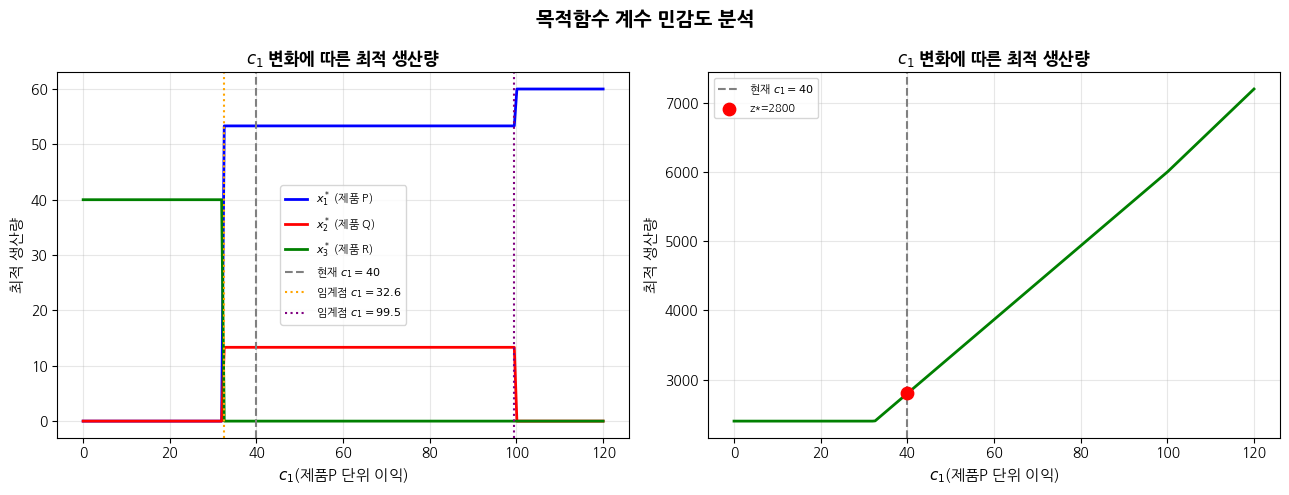

c1의 허용 범위: 32.6<=c1<=99.5(현재 기저 유지)
c1<32.6 -> 기저 변경: x1=0, x2=0, x3=40 이 최적
c1>99.5 -> 기저 변경: x1=59.9, x2=0, x3=0이 최적


In [21]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

def solve_lp(c1_val, c2_val=50, c3_val=60, b1=120, b2=80, b3=100):
    #LP를 주어진 파라미터로 풀고 (x1,x2,z) 반환
    s = pywraplp.Solver.CreateSolver('GLOP')
    INF = s.infinity()
    P = s.NumVar(0,INF, 'P')
    Q = s.NumVar(0,INF, 'Q')
    R = s.NumVar(0,INF, 'R')
    
    s.Add(2*P+Q+3*R <= b1)
    s.Add(P+2*Q+2*R <= b2)
    s.Add(P+2*Q+2*R <= b3)
    s.Maximize(c1_val*P + c2_val*Q + c3_val*R)
    
    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        return P.solution_value(), Q.solution_value(), R.solution_value(), s.Objective().Value()
    
    return None, None, None

c1_range = np.linspace(0,120,200)
x1_vals, x2_vals, x3_vals, z_vals = [], [], [], []
for c1v in c1_range:
    xv1, xv2, xv3, zv = solve_lp(c1v)
    x1_vals.append(xv1); x2_vals.append(xv2); x3_vals.append(xv3); z_vals.append(zv)
    # if (xv2 == 0)&(xv3 == 0):
    #     print(xv1)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
ax.plot(c1_range, x1_vals, 'b-', lw=2, label=r'$x_1^*$ (제품 P)')
ax.plot(c1_range, x2_vals, 'r-', lw=2, label=r'$x_2^*$ (제품 Q)')
ax.plot(c1_range, x3_vals, 'g-', lw=2, label=r'$x_3^*$ (제품 R)')
ax.axvline(40,color='gray', ls='--', label='현재 $c_1=40$')
ax.axvline(32.6,color='orange', ls=':', lw=1.5, label='임계점 $c_1=32.6$')
ax.axvline(99.5,color='purple', ls=':', lw=1.5, label='임계점 $c_1=99.5$')
ax.set_xlabel(r'$c_1$(제품P 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_1$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(c1_range, z_vals, 'g-', lw=2)
ax.axvline(40, color='gray', ls='--', label='현재 $c_1=40$')
ax.scatter([40],[2800],color='red', s=80, zorder=5, label='z*=2800')
ax.set_xlabel(r'$c_1$(제품P 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_1$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('목적함수 계수 민감도 분석', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('c1의 허용 범위: 32.6<=c1<=99.5(현재 기저 유지)')
print('c1<32.6 -> 기저 변경: x1=0, x2=0, x3=40 이 최적')
print('c1>99.5 -> 기저 변경: x1=59.9, x2=0, x3=0이 최적')


c2(제품Q이익) 변화

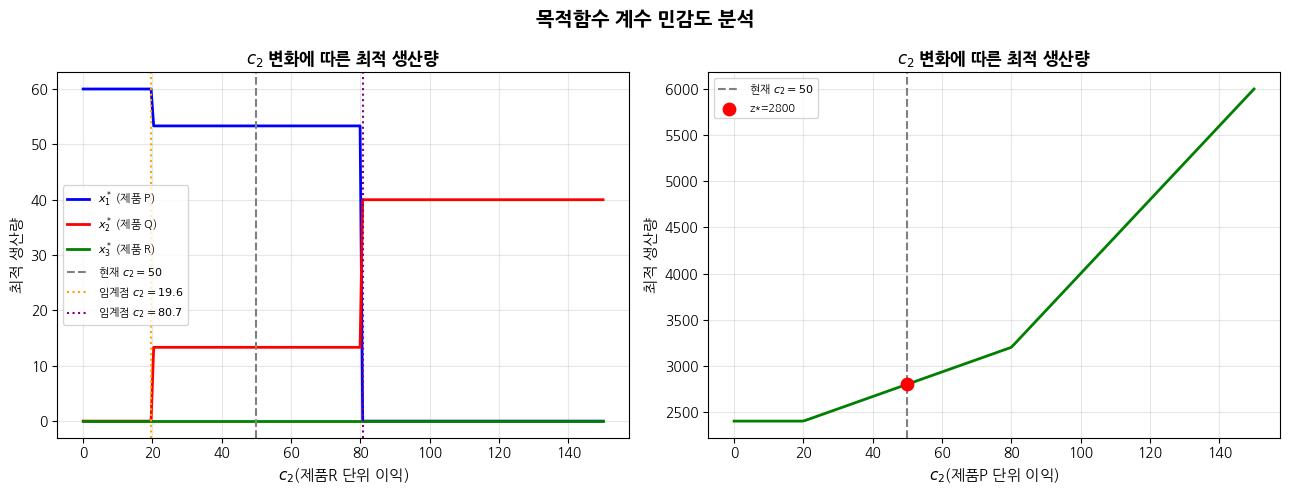

c2의 허용 범위: 32.6<=c2<=99.5(현재 기저 유지)
c2<19.6 -> 기저 변경: x1=59.9, x2=0, x3=0 이 최적
c2>80.7 -> 기저 변경: x1=0, x2=40, x3=0이 최적


In [36]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

def solve_lp(c2_val, c1_val=40, c3_val=60, b1=120, b2=80, b3=100):
    #LP를 주어진 파라미터로 풀고 (x1,x2,z) 반환
    s = pywraplp.Solver.CreateSolver('GLOP')
    INF = s.infinity()
    P = s.NumVar(0,INF, 'P')
    Q = s.NumVar(0,INF, 'Q')
    R = s.NumVar(0,INF, 'R')
    
    s.Add(2*P+Q+3*R <= b1)
    s.Add(P+2*Q+2*R <= b2)
    s.Add(P+2*Q+2*R <= b3)
    s.Maximize(c1_val*P + c2_val*Q + c3_val*R)
    
    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        return P.solution_value(), Q.solution_value(), R.solution_value(), s.Objective().Value()
    
    return None, None, None

c2_range = np.linspace(0,150,200)
x1_vals, x2_vals, x3_vals, z_vals = [], [], [], []
for c2v in c2_range:
    xv1, xv2, xv3, zv = solve_lp(c2v)
    x1_vals.append(xv1); x2_vals.append(xv2); x3_vals.append(xv3); z_vals.append(zv)
    # if c2v <= 50:
    #     print(zv)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
ax.plot(c2_range, x1_vals, 'b-', lw=2, label=r'$x_1^*$ (제품 P)')
ax.plot(c2_range, x2_vals, 'r-', lw=2, label=r'$x_2^*$ (제품 Q)')
ax.plot(c2_range, x3_vals, 'g-', lw=2, label=r'$x_3^*$ (제품 R)')
ax.axvline(50,color='gray', ls='--', label='현재 $c_2=50$')
ax.axvline(19.6,color='orange', ls=':', lw=1.5, label='임계점 $c_2=19.6$')
ax.axvline(80.7,color='purple', ls=':', lw=1.5, label='임계점 $c_2=80.7$')
ax.set_xlabel(r'$c_2$(제품R 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_2$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(c2_range, z_vals, 'g-', lw=2)
ax.axvline(50, color='gray', ls='--', label='현재 $c_2=50$')
ax.scatter([50],[2800],color='red', s=80, zorder=5, label='z*=2800')
ax.set_xlabel(r'$c_2$(제품P 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_2$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('목적함수 계수 민감도 분석', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('c2의 허용 범위: 32.6<=c2<=99.5(현재 기저 유지)')
print('c2<19.6 -> 기저 변경: x1=59.9, x2=0, x3=0 이 최적')
print('c2>80.7 -> 기저 변경: x1=0, x2=40, x3=0이 최적')


c3(제품R이익) 변화

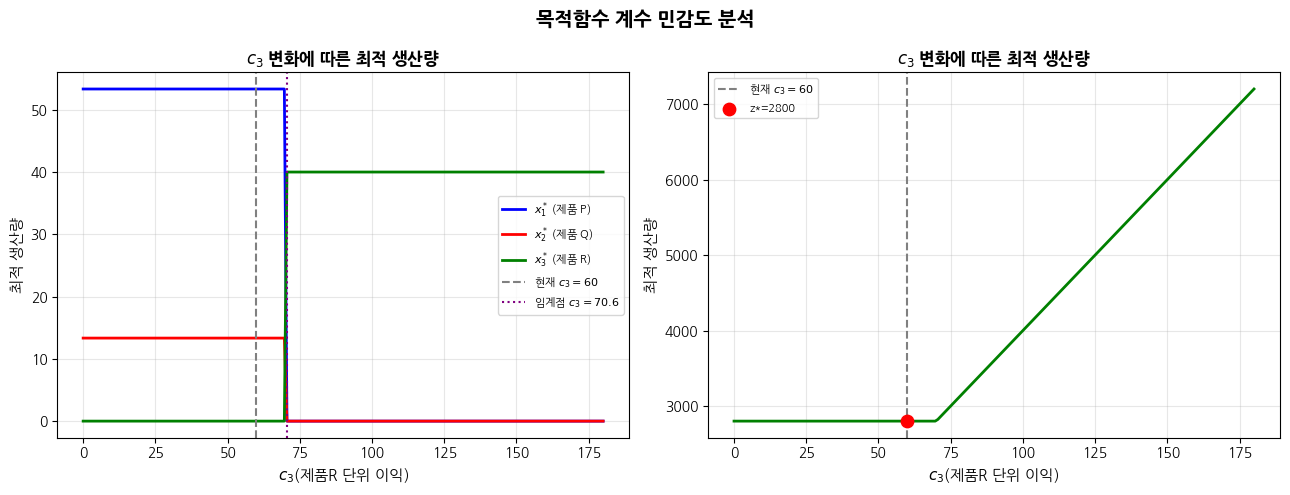

c1의 허용 범위: c3<=70.6(현재 기저 유지)
c3>70.6 -> 기저 변경: x1=0, x2=0, x3=39.9이 최적


In [20]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

def solve_lp(c3_val, c1_val=40, c2_val=50, b1=120, b2=80, b3=100):
    #LP를 주어진 파라미터로 풀고 (x1,x2,z) 반환
    s = pywraplp.Solver.CreateSolver('GLOP')
    INF = s.infinity()
    P = s.NumVar(0,INF, 'P')
    Q = s.NumVar(0,INF, 'Q')
    R = s.NumVar(0,INF, 'R')
    
    s.Add(2*P+Q+3*R <= b1)
    s.Add(P+2*Q+2*R <= b2)
    s.Add(P+2*Q+2*R <= b3)
    s.Maximize(c1_val*P + c2_val*Q + c3_val*R)
    
    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        return P.solution_value(), Q.solution_value(), R.solution_value(), s.Objective().Value()
    
    return None, None, None

c3_range = np.linspace(0,180,200)
x1_vals, x2_vals, x3_vals, z_vals = [], [], [], []
for c3v in c3_range:
    xv1, xv2, xv3, zv = solve_lp(c3v)
    x1_vals.append(xv1); x2_vals.append(xv2); x3_vals.append(xv3); z_vals.append(zv)
    # if xv1 == 0:
    #     print(xv3)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
ax.plot(c3_range, x1_vals, 'b-', lw=2, label=r'$x_1^*$ (제품 P)')
ax.plot(c3_range, x2_vals, 'r-', lw=2, label=r'$x_2^*$ (제품 Q)')
ax.plot(c3_range, x3_vals, 'g-', lw=2, label=r'$x_3^*$ (제품 R)')
ax.axvline(60,color='gray', ls='--', label='현재 $c_3=60$')
ax.axvline(70.6,color='purple', ls=':', lw=1.5, label='임계점 $c_3=70.6$')
ax.set_xlabel(r'$c_3$(제품R 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_3$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(c3_range, z_vals, 'g-', lw=2)
ax.axvline(60, color='gray', ls='--', label='현재 $c_3=60$')
ax.scatter([60],[2800],color='red', s=80, zorder=5, label='z*=2800')
ax.set_xlabel(r'$c_3$(제품R 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_3$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('목적함수 계수 민감도 분석', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('c1의 허용 범위: c3<=70.6(현재 기저 유지)')
print('c3>70.6 -> 기저 변경: x1=0, x2=0, x3=39.9이 최적')


RHS 민감도 - Shadow Price 유효 범위

In [ ]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

b1_range = np.linspace(2, 16, 200)
z_b1, sp_b1 = [], []

for b1v in b1_range:
    s = pywraplp.Solver.CreateSolver('GLOP')

    # 결정 변수
    INF = s.infinity()
    x1 = s.NumVar(0,INF,'x1') 
    x2 = s.NumVar(0,INF, 'x2')

    # 제약 조건
    ct1 = s.Add(2*x1 + x2 <= b1v)
    s.Add(x1+3*x2<=9)

    # 목적 함수
    s.Maximize(3*x1 + 5 * x2)

    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        z_b1.append(s.Objective().Value())
        sp_b1.append(ct1.dual_value())
    else:
        z_b1.append(np.nan); sp_b1.append(np.nan) 

fig, axes = plt.subplots(1,2, figsize=(13,5))

ax = axes[0]
ax.plot(b1_range, z_b1, 'b-', lw=2)
ax.axvline(8,color='gray', ls='--', label='현재 $b_1=8$')
ax.scatter([8],[19],color='red', s=80, zorder=5, label='현재z*=19')
b1_tan=np.array([4,14])
ax.plot(b1_tan, 19+0.8*(b1_tan-8), 'r--', alpha=0.6, label='기울기=0.8 (shadow price)')
ax.set_xlabel(r'$b_1$(기계 가용 시간)', fontsize=11)
ax.set_ylabel('최적 이익 *', fontsize=11)
ax.set_title(r'$b_1$ 변화에 따른 최적 이익', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(b1_range, sp_b1, 'r-', lw=2)
ax.axvline(8, color='gray', ls='--', label='현재 $b_1=8$')
ax.axhline(0.8, color='orange', ls=':', label='y1*=0.8$')
ax.fill_between([3,12], [0,0], [1,1], alpha=0.1, color='green', label='Shdow price 유효 구간')
ax.set_xlabel(r'$b_1$(기계 가용 시간)', fontsize=11)
ax.set_ylabel('Shadow Price $y_1', fontsize=11)
ax.set_title('Shadow Price 유효 범위', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-0.1, 1.8)

plt.suptitle('RHS 민감도 분석(기계 제약 b1)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('기계 제약 (b1=8): shadow price y1* = 0.80 만원/시간')
print('조립 제약 (b2=9): shadow price y2* = 1.40 만원/시간')
print('-> 기계 1시간 추가 -> 이익 +0.80만원')
print('-> 조립 1시간 추가 -> 이익 +1.40만원')
print('조립 인력 확충이 더 효과적!')